Day 8: Building a Simple Linear Regression Model

Goal: To introduce Machine Learning practically by building a Simple Linear Regression model to predict calories burned based on workout duration.

What is Simple Linear Regression?

Simple Linear Regression is a foundational machine learning algorithm. It attempts to predict a "Target" variable (what we want to guess) using a single "Feature" variable (what we already know) by drawing a straight line through our data points that best captures the trend.

In our case:

Feature (X): Duration of the workout.

Target (y): Calories burned.

Step 1. Setting Up Our Environment and Loading Data
Before we can perform machine learning, we need to bring in our toolbox. In Python, these tools are called "libraries":

- Pandas: Helps us organize our data into readable tables (DataFrames).

- Matplotlib & Seaborn: Help us draw graphs and charts to visualize our data.

- Scikit-Learn (sklearn): The core machine learning library that contains our Linear Regression math and evaluation tools.

In [1]:
# Loading the Necessary Packages
import pandas as pd # 'pandas' is used for data manipulation and analysis
import matplotlib.pyplot as plt # 'matplotlib.pyplot' is used to create static, interactive, and animated visualizations
import seaborn as sns # 'seaborn' is a data visualization library based on matplotlib that makes statistical graphics look better
from sklearn.model_selection import train_test_split # 'train_test_split' helps us split our dataset into a training set and a testing set
from sklearn.linear_model import LinearRegression # 'LinearRegression' is the actual machine learning algorithm we will use to train our model
from sklearn.metrics import mean_squared_error # 'mean_squared_error' is a metric used to evaluate how close our predictions are to the actual values

# Loading the Dataset
df = pd.read_csv('data.csv')

# This line removes any rows that contain missing values (NaN) to prevent errors during training
df.dropna(inplace=True)

# This displays the first 5 rows of our dataset so we can inspect it
df.head()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


Step 2. Exploratory Data Analysis (EDA)
Machine Learning shouldn't be a black box! Before feeding data into an algorithm, we must look at it. We are going to plot a scatter graph of Duration vs Calories.

- We are looking for a positive correlation as the duration of a workout increases, does the number of calories burned also increase? If the points look like they generally form a line pointing upwards, Linear Regression is a great choice!

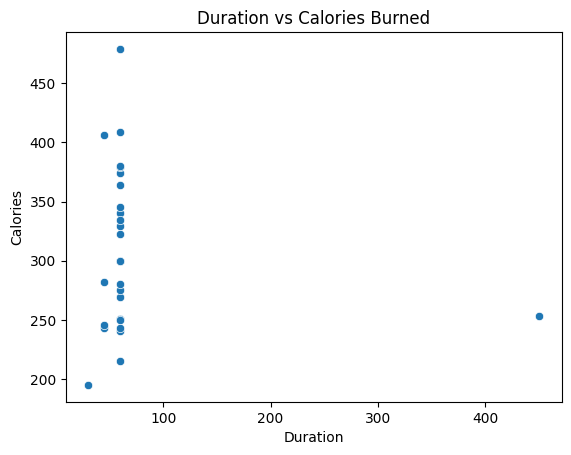

In [2]:
# Creates a scatter plot using seaborn, putting 'Duration' on the x-axis and 'Calories' on the y-axis
sns.scatterplot(x='Duration', y='Calories', data=df)

# Sets the title of our plot
plt.title('Duration vs Calories Burned')

# Displays the plot on the screen
plt.show()

Step 3. Preparing and Splitting the Data
In Machine Learning, we cannot test our model using the exact same data it used to learn. That would be like giving a student the answer key before an exam!

To fix this, we split our data into two groups:

- Training Data (80%): The model uses this to learn the relationship between Duration and Calories.

- Testing Data (20%): The model has never seen this data. We use it to test how well the model guesses.

In [3]:
X = df[['Duration']] # We extract the 'Duration' column as a 2D array (DataFrame) because scikit-learn requires 2D inputs for features

y = df['Calories'] # We extract the 'Calories' column as a 1D array (Series) for our target variable

# We split X and y into training (80%) and testing (20%) sets.
# 'random_state=42' ensures that the random split is exactly the same every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Prints the number of rows in the training set to verify the split
print(f"Training data size: {X_train.shape[0]} rows")

# Prints the number of rows in the testing set to verify the split
print(f"Testing data size: {X_test.shape[0]} rows")

Training data size: 23 rows
Testing data size: 6 rows


Step 4. Training the Machine Learning Model
Now comes the actual Machine Learning! We will initialize our Linear Regression model and tell it to fit (learn) our training data.

When it learns, it is mathematically calculating the Line of Best Fit. It finds the starting point (Intercept) and the steepness of the line (Coefficient/Slope).

In [4]:
# Creates an instance of the LinearRegression algorithm and assigns it to the variable 'model'
model = LinearRegression()

# The 'fit' method trains the model by finding the best mathematical relationship (line of best fit) between X_train and y_train
model.fit(X_train, y_train)

# Prints the Y-intercept of the line of best fit calculated by the model
print(f"Intercept: {model.intercept_}")

# Prints the slope (coefficient) of the line, which tells us how much Calories increase per unit of Duration
print(f"Coefficient: {model.coef_[0]}")

Intercept: 330.0412977200424
Coefficient: -0.16744918699186984


Step 5: Making Predictions and Evaluating Performance
Our model is fully trained. Now, we will give it the X_test (Durations it has never seen before) and ask it to predict the Calories.

To see how well it did, we calculate the Mean Squared Error (MSE).

This metric measures the average distance between our model's guesses and the actual true values.

The lower the MSE, the better our model performed! We will also draw a final graph showing our model's Line of Best Fit slicing through the data points.



Mean Squared Error: 7458.76


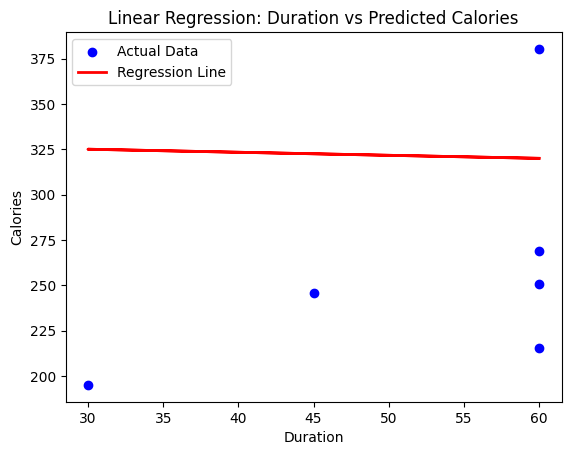

In [5]:
# The 'predict' method uses the trained model to guess the Calories for the unseen 'Duration' data in X_test
predictions = model.predict(X_test)

# Calculates the Mean Squared Error (MSE) by comparing the model's 'predictions' against the actual 'y_test' values
mse = mean_squared_error(y_test, predictions)

# Prints out the final Mean Squared Error to evaluate accuracy
print(f"Mean Squared Error: {mse:.2f}")

# Creates a scatter plot of the actual testing data points in blue
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

# Draws the straight red regression line using our predictions
plt.plot(X_test, predictions, color='red', linewidth=2, label='Regression Line')

# Adds a label to the X-axis
plt.xlabel('Duration')

# Adds a label to the Y-axis
plt.ylabel('Calories')

# Adds a title to the visualization
plt.title('Linear Regression: Duration vs Predicted Calories')

# Adds a legend to differentiate the actual data from the regression line
plt.legend()

# Displays the final plot
plt.show()